## Manual analysis of total_sources 

List of sources that were selected to be part of our sample from a manual whitelist feature analysis and expansion to the whole raw sample 

### Set-up


In [4]:
import gc
import glob
import json
import os
from pathlib import Path

# Bridage des threads pour Numpy, Pandas et Scikit-Learn (laisse le CPU à DuckDB)
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"
os.environ["OPENBLAS_NUM_THREADS"] = "4"
os.environ["NUMEXPR_NUM_THREADS"] = "4"

import duckdb
from IPython.display import HTML, display
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns

# Configuration esthétique globale
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.family"] = "sans-serif"
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
pd.set_option("display.max_columns", 30)

print("✔ Librairies importées et environnement configuré.")

✔ Librairies importées et environnement configuré.


In [5]:
# ==============================================================================
# 1. DÉFINITION DES CHEMINS (À adapter si tes fichiers sont dans un autre dossier)
# ==============================================================================
DATA_DIR = Path("/data/gdelt/gdelt_parquet_db")
SOURCE_MAP_PATH = Path("/data/gdelt/gdelt_sources_mapping.json")
RETAINED_IDS_PATH = Path("liste_ids_retenus.txt")
DOMAINS_PARQUET_PATH = "data/domains/domains_*.parquet"

# ==============================================================================
# 2. INITIALISATION ET PARAMÉTRAGE DE DUCKDB
# ==============================================================================
con = duckdb.connect()

# Réglage musclé pour ton grand serveur partagé (128 Go RAM / 16 threads en standard)
con.execute("PRAGMA memory_limit='128GB'")
con.execute("PRAGMA threads=16")

# 3. Chargement du dictionnaire JSON (Traduction ID <-> Nom de domaine)
with open(SOURCE_MAP_PATH, "r", encoding="utf-8") as f:
  source_map = json.load(f)

src_df = pd.DataFrame({
    "SourceCommonName_ID": [int(k) for k in source_map["id_to_source"].keys()],
    "SourceCommonName": list(source_map["id_to_source"].values()),
})
con.register("src_map", src_df)

# 4. Chargement de TA LISTE PROPRE d'ID retenus dans une table DuckDB dédiée
con.execute(f"""
    CREATE OR REPLACE TABLE retained_ids AS 
    SELECT column0::BIGINT AS id 
    FROM read_csv('{RETAINED_IDS_PATH}', header=False)
""")

nb_ids = con.execute("SELECT COUNT(*) FROM retained_ids").fetchone()[0]
print(
    f"✔ DuckDB initialisé. Table 'retained_ids' chargée ({nb_ids:,} médias"
    " légitimes)."
)

✔ DuckDB initialisé. Table 'retained_ids' chargée (13,334 médias légitimes).


In [6]:
glob_pattern = str(DATA_DIR / "gdelt_*.parquet")

print(
    "⏳ Création de la vue maîtresse 'gkg_clean' (Filtrage sur échantillon"
    " propre & enrichissement)..."
)

con.execute(f"""
    CREATE OR REPLACE VIEW gkg_clean AS
    
    WITH raw_filtered AS (
        -- 1. Nettoyage initial : dates valides, exclusion ligne corrompue et thèmes vides
        SELECT *
        FROM read_parquet('{glob_pattern}')
        WHERE regexp_matches(CAST(DATE AS VARCHAR), '^\d{{14}}$')
          AND GKGRECORDID != '20210925181500-T1111'
          AND EnhancedThemes IS NOT NULL 
          AND EnhancedThemes != ''
    ),
    
    repaired AS (
        -- 2. Réparation de l'identifiant (si 0 ou NULL, on tente de matcher le nom de domaine via src_map)
        SELECT 
            r.* EXCLUDE (SourceCommonName_ID),
            CASE 
                WHEN COALESCE(r.SourceCommonName_ID, 0) = 0 THEN m.SourceCommonName_ID
                ELSE r.SourceCommonName_ID
            END AS SourceCommonName_ID
        FROM raw_filtered r
        LEFT JOIN src_map m 
          ON RTRIM(regexp_extract(r.DocumentIdentifier, 'https?://(?:www\.)?([^/?:]+)', 1), '.') = m.SourceCommonName
    )
    
    -- 3. FILTRAGE STRICT SUR L'ÉCHANTILLON ET ENRICHISSEMENT WIKIDATA
    SELECT 
        rep.*,
        w.medialabel,
        w.typelabel,
        w.countrylabel,
        w.inception,
        CASE WHEN w.Src_ID IS NOT NULL THEN 1 ELSE 0 END AS is_wiki
    FROM repaired rep
    -- 🔥 LE FILTRE CLÉ : Jointure interne avec ta liste des sources retenues !
    INNER JOIN retained_ids rid 
      ON rep.SourceCommonName_ID = rid.id
    -- Enrichissement optionnel : si la source est dans Wikidata, on récupère ses labels
    LEFT JOIN (
        SELECT 
            id AS Src_ID, 
            medialabel, 
            typelabel, 
            countrylabel, 
            inception
        FROM read_parquet('{DOMAINS_PARQUET_PATH}')
        QUALIFY ROW_NUMBER() OVER (PARTITION BY id ORDER BY inception ASC, countrylabel ASC) = 1
    ) w ON rep.SourceCommonName_ID = w.Src_ID;
""")

print(
    "✔ Vue 'gkg_clean' prête ! Elle ne contient que les articles de ton"
    " échantillon sélectionné."
)

⏳ Création de la vue maîtresse 'gkg_clean' (Filtrage sur échantillon propre & enrichissement)...
✔ Vue 'gkg_clean' prête ! Elle ne contient que les articles de ton échantillon sélectionné.


<>:57: SyntaxWarning: invalid escape sequence '\d'
<>:57: SyntaxWarning: invalid escape sequence '\.'
<>:57: SyntaxWarning: invalid escape sequence '\d'
<>:57: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_2124764/1892980978.py:57: SyntaxWarning: invalid escape sequence '\d'
  """)
/tmp/ipykernel_2124764/1892980978.py:57: SyntaxWarning: invalid escape sequence '\.'
  """)


In [6]:
print("⏳ Calcul de la volumétrie globale sur ton échantillon...")

# 1. Requête rapide de vérification
df_check = con.execute("""
    SELECT 
        COUNT(*) AS total_articles_disponibles,
        COUNT(DISTINCT SourceCommonName_ID) AS medias_actifs,
        MIN(strptime(substr(CAST(DATE AS VARCHAR), 1, 8), '%Y%m%d')::DATE) AS date_min,
        MAX(strptime(substr(CAST(DATE AS VARCHAR), 1, 8), '%Y%m%d')::DATE) AS date_max,
        SUM(is_wiki) AS articles_avec_metadata_wiki
    FROM gkg_clean;
""").df()

# 2. Affichage du résumé
display(df_check.style.format({
    "total_articles_disponibles": "{:,.0f}",
    "medias_actifs": "{:,.0f}",
    "articles_avec_metadata_wiki": "{:,.0f}"
}))

# 3. Aperçu des 3 premiers articles au hasard pour vérifier la structure
print("\n👀 Aperçu de 3 articles au hasard dans la vue propre :")
display(con.execute("""
    SELECT 
        GKGRECORDID, 
        SourceCommonName_ID, 
        medialabel, 
        countrylabel, 
        substr(DocumentIdentifier, 1, 60) || '...' AS URL,
        substr(EnhancedThemes, 1, 80) || '...' AS Themes_extrait
    FROM gkg_clean 
    USING SAMPLE 3;
""").df())

⏳ Calcul de la volumétrie globale sur ton échantillon...


RuntimeError: Query interrupted

In [7]:
def generer_statistiques(con, table_name="gkg_inter", col_source="domain", col_date="date"):
    """
    Génère un tableau de bord de statistiques descriptives réutilisable pour n'importe quelle vue GDELT.
    """
    
    # Extraction de l'année robuste : fonctionne si 'date' est un entier (20210512) ou un vrai TIMESTAMP
    year_expr = f"CAST(SUBSTRING(CAST({col_date} AS VARCHAR), 1, 4) AS INTEGER)"
    
    query = f"""
    -- 1. VOLUMÉTRIE GLOBALE
    SELECT '1. Volumétrie' AS Categorie, 'Nombre total d''articles' AS Indicateur, 
           CAST(COUNT(*) AS VARCHAR) AS Valeur, 'ℹ️' AS Statut 
    FROM {table_name}
    
    UNION ALL
    SELECT '1. Volumétrie', 'Nombre de sources uniques', 
           CAST(COUNT(DISTINCT {col_source}) AS VARCHAR), 'ℹ️' 
    FROM {table_name}
    
    UNION ALL
    SELECT '1. Volumétrie', 'Nombre moyen d''articles par source', 
           CAST(ROUND(COUNT(*) / CAST(COUNT(DISTINCT {col_source}) AS FLOAT), 1) AS VARCHAR), 'ℹ️' 
    FROM {table_name}

    -- 2. DYNAMIQUE TEMPORELLE
    UNION ALL
    SELECT '2. Dynamique Temporelle', 'Nombre moyen de sources actives par an', 
           CAST(ROUND(AVG(nb_src), 1) AS VARCHAR), 'ℹ️' 
    FROM (
        SELECT {year_expr} AS yr, COUNT(DISTINCT {col_source}) AS nb_src 
        FROM {table_name} 
        GROUP BY {year_expr}
    ) AS sub_sources_year

    UNION ALL
    SELECT '2. Dynamique Temporelle', 'Nombre moyen d''articles par an et par source', 
           CAST(ROUND(AVG(nb_arts), 1) AS VARCHAR), 'ℹ️' 
    FROM (
        SELECT {col_source}, {year_expr}, COUNT(*) AS nb_arts 
        FROM {table_name} 
        GROUP BY {col_source}, {year_expr}
    ) AS sub_arts_year

    -- 3. PÉRENNITÉ DES SOURCES
    UNION ALL
    SELECT '3. Pérennité', 'Répartition des sources selon le nb d''années d''activité', 
           STRING_AGG(nb_yrs || ' an(s): ' || nb_src || ' sources', '  |  ' ORDER BY nb_yrs), 'ℹ️' 
    FROM (
        SELECT nb_yrs, COUNT(*) AS nb_src 
        FROM (
            SELECT {col_source}, COUNT(DISTINCT {year_expr}) AS nb_yrs 
            FROM {table_name} 
            GROUP BY {col_source}
        ) AS sub_count_years
        GROUP BY nb_yrs
    ) AS sub_dist_years
    
    ORDER BY Categorie, Indicateur;
    """
    
    # Exécution de la requête
    df_stats = con.execute(query).df()
    
    # Application du style comme dans votre code
    styled_dashboard = df_stats.style.set_properties(**{'text-align': 'left'}, subset=['Categorie', 'Indicateur', 'Valeur'])\
                                     .set_properties(**{'text-align': 'center'}, subset=['Statut'])\
                                     .set_caption(f"<b>Statistiques descriptives - Table/Vue : {table_name}</b>")\
                                     .hide(axis="index")
    return styled_dashboard

### Random sample analysis 

#### Analysis of 100 sources, randomly chosen among all the selected sources 

In [ ]:
print("Tirage aléatoire de 1000 sources dans l'échantillon retenu...\n")

# 1. Requête SQL : Jointure avec le dictionnaire des noms et tirage aléatoire
df_sample_100 = con.execute("""
    SELECT 
        r.id AS SourceCommonName_ID,
        COALESCE(m.SourceCommonName, 'Domaine inconnu (' || r.id || ')') AS SourceCommonName
    FROM retained_ids r
    LEFT JOIN src_map m ON r.id = m.SourceCommonName_ID
    ORDER BY random()
    LIMIT 100;
""").df()

# 2. Réinitialisation de l'index pour avoir un comptage propre de 1 à 100
df_sample_100.index = range(1, len(df_sample_100) + 1)
df_sample_100.index.name = '#'

# 3. AFFICHAGE EN GRILLE DE TEXTE (4 colonnes) pour un balayage visuel ultra-rapide
domaines = df_sample_100['SourceCommonName'].tolist()
n_cols = 4
n_rows = (len(domaines) + n_cols - 1) // n_cols

print("BALAYAGE RAPIDE — 1000 médias tirés au hasard :\n" + "="*85)
for r in range(n_rows):
    row_items = []
    for c in range(n_cols):
        idx = r + c * n_rows
        if idx < len(domaines):
            # On formate chaque nom sur 20 caractères pour aligner les colonnes
            row_items.append(f"{idx+1:3d}. {domaines[idx]:<18}")
    print(" | ".join(row_items))

print("\n" + "="*85)

# 4. AFFICHAGE DU DATAFRAME COMPLET (Pour inspection détaillée si besoin)
# On force Pandas à afficher les 100 lignes sans tronquer
with pd.option_context('display.max_rows', 1000):
    display(df_sample_100.style.set_properties(**{
        'font-weight': 'bold', 
        'text-align': 'left'
    }))

Tirage aléatoire de 1000 sources dans l'échantillon retenu...

BALAYAGE RAPIDE — 1000 médias tirés au hasard :
  1. wapa.pe            |  26. turkiyegazetesi.com.tr |  51. teleradioerre.it   |  76. fudzilla.com      
  2. ecoportal.net      |  27. wcjc.com           |  52. lavozdemichoacan.com.mx |  77. balticbusinessnews.com
  3. fool.ca            |  28. nikvesti.com       |  53. istanbulhaber.com.tr |  78. wcti12.com        
  4. epochtimes.com.tw  |  29. oskaloosa.com      |  54. diarioeyipantla.com |  79. sciencerecorder.com
  5. politis.fr         |  30. zive.sk            |  55. nogalesinternational.com |  80. rttnews.com       
  6. hl.co.uk           |  31. clutchfans.net     |  56. jpnn.com           |  81. economynext.com   
  7. bclocalnews.com    |  32. sonapresse.com     |  57. mtexpress.com      |  82. arka.am           
  8. pnp.de             |  33. turmush.kg         |  58. ukrinform.ua       |  83. observer-reporter.com
  9. goldentranscript.net |  34. khm.depo.ua   

,SourceCommonName_ID,SourceCommonName
#,,
1,28616,wapa.pe
2,29714,ecoportal.net
3,8909,fool.ca
4,61100,epochtimes.com.tw
5,28365,politis.fr
6,20541,hl.co.uk
7,159809,bclocalnews.com
8,26153,pnp.de
9,125597,goldentranscript.net


"You are a research assistant in economics and I give you this list of 1000 sources randmoly chosen from my sample. I want to know how many are not newspapers that discuss economic, politic and business topics"


### Descriptive stats 

In [ ]:
audit_query = """
-- 1. VOLUME ET UNICITÉ
SELECT '1. Volume & Unicité' AS Categorie, 'Nombre total d''articles' AS Indicateur, CAST(COUNT(*) AS VARCHAR) AS Valeur, 'ℹ️' AS Statut FROM gkg_clean
UNION ALL
SELECT '1. Volume & Unicité', 'Doublons sur GKGRECORDID', CAST(COUNT(*) - COUNT(DISTINCT GKGRECORDID) AS VARCHAR), CASE WHEN COUNT(*) = COUNT(DISTINCT GKGRECORDID) THEN '✅' ELSE '⚠️' END FROM gkg_clean

-- 2. CONFORMITÉ DES FORMATS
UNION ALL
SELECT '2. Conformité', 'URLs invalides (pas HTTP) sur Source=1', CAST(COUNT(*) AS VARCHAR), CASE WHEN COUNT(*) = 0 THEN '✅' ELSE '⚠️' END FROM gkg_clean WHERE SourceCollectionIdentifier = 1 AND DocumentIdentifier NOT ILIKE 'http%'
UNION ALL
SELECT '2. Conformité', 'IsTranslingual (valeurs hors 0/1)', CAST(COUNT(*) AS VARCHAR), CASE WHEN COUNT(*) = 0 THEN '✅' ELSE '⚠️' END FROM gkg_clean WHERE IsTranslingual NOT IN (0, 1)

-- 3. COMPLÉTUDE
UNION ALL
SELECT '3. Complétude (Critique)', 'GKGRECORDID / DATE / URL (% Vides)', CAST(ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM gkg_clean), 4) AS VARCHAR) || ' %', CASE WHEN COUNT(*) = 0 THEN '✅' ELSE '⚠️' END FROM gkg_clean WHERE GKGRECORDID IS NULL OR DATE IS NULL OR DocumentIdentifier IS NULL OR DocumentIdentifier = ''
UNION ALL
SELECT '3. Complétude (Information)', 'EnhancedThemes (% Vides)', CAST(ROUND(100.0 * SUM(CASE WHEN EnhancedThemes IS NULL OR EnhancedThemes = '' THEN 1 ELSE 0 END) / COUNT(*), 2) AS VARCHAR) || ' %', 'ℹ️' FROM gkg_clean
UNION ALL
SELECT '3. Complétude (Information)', 'EnhancedLocations (% Vides)', CAST(ROUND(100.0 * SUM(CASE WHEN EnhancedLocations IS NULL OR EnhancedLocations = '' THEN 1 ELSE 0 END) / COUNT(*), 2) AS VARCHAR) || ' %', 'ℹ️' FROM gkg_clean
UNION ALL
SELECT '3. Complétude (Information)', 'Persons (% Vides)', CAST(ROUND(100.0 * SUM(CASE WHEN Persons IS NULL OR Persons = '' THEN 1 ELSE 0 END) / COUNT(*), 2) AS VARCHAR) || ' %', 'ℹ️' FROM gkg_clean
UNION ALL
SELECT '3. Complétude (Information)', 'Organizations (% Vides)', CAST(ROUND(100.0 * SUM(CASE WHEN Organizations IS NULL OR Organizations = '' THEN 1 ELSE 0 END) / COUNT(*), 2) AS VARCHAR) || ' %', 'ℹ️' FROM gkg_clean

-- 4. PROFILING NUMÉRIQUE
UNION ALL
SELECT '4. Profiling Numérique', 'Tone (Min | Q1 | Médiane | Moyenne | Q3 | Max)', 
    CAST(ROUND(MIN(Tone), 1) AS VARCHAR) || ' | ' || CAST(ROUND(APPROX_QUANTILE(Tone, 0.25), 1) AS VARCHAR) || ' | ' || CAST(ROUND(APPROX_QUANTILE(Tone, 0.50), 1) AS VARCHAR) || ' | ' || CAST(ROUND(AVG(Tone), 2) AS VARCHAR) || ' | ' || CAST(ROUND(APPROX_QUANTILE(Tone, 0.75), 1) AS VARCHAR) || ' | ' || CAST(ROUND(MAX(Tone), 1) AS VARCHAR), 
    CASE WHEN MIN(Tone) >= -100 AND MAX(Tone) <= 100 THEN '✅' ELSE '⚠️' END FROM gkg_clean
UNION ALL
SELECT '4. Profiling Numérique', 'WordCount (Min | Q1 | Médiane | Moyenne | Q3 | Max)', 
    CAST(MIN(WordCount) AS VARCHAR) || ' | ' || CAST(CAST(APPROX_QUANTILE(WordCount, 0.25) AS INTEGER) AS VARCHAR) || ' | ' || CAST(CAST(APPROX_QUANTILE(WordCount, 0.50) AS INTEGER) AS VARCHAR) || ' | ' || CAST(ROUND(AVG(WordCount), 0) AS VARCHAR) || ' | ' || CAST(CAST(APPROX_QUANTILE(WordCount, 0.75) AS INTEGER) AS VARCHAR) || ' | ' || CAST(MAX(WordCount) AS VARCHAR), 
    CASE WHEN MIN(WordCount) >= 0 THEN '✅' ELSE '⚠️' END FROM gkg_clean


-- 5. PROFILING SÉMANTIQUE (Entités)
UNION ALL
SELECT '5. Profiling Sémantique', 'Thèmes uniques (Min | Q1 | Médiane | Moyenne | Q3 | Max)', 
    CAST(MIN(val) AS VARCHAR) || ' | ' || CAST(CAST(APPROX_QUANTILE(val, 0.25) AS INTEGER) AS VARCHAR) || ' | ' || CAST(CAST(APPROX_QUANTILE(val, 0.50) AS INTEGER) AS VARCHAR) || ' | ' || CAST(ROUND(AVG(val), 1) AS VARCHAR) || ' | ' || CAST(CAST(APPROX_QUANTILE(val, 0.75) AS INTEGER) AS VARCHAR) || ' | ' || CAST(MAX(val) AS VARCHAR), 
    'ℹ️' FROM (SELECT CASE WHEN EnhancedThemes = '' THEN 0 ELSE ARRAY_LENGTH(string_split(EnhancedThemes, ';')) END AS val FROM gkg_clean)
UNION ALL
SELECT '5. Profiling Sémantique', 'Personnes uniques (Min | Q1 | Médiane | Moyenne | Q3 | Max)', 
    CAST(MIN(val) AS VARCHAR) || ' | ' || CAST(CAST(APPROX_QUANTILE(val, 0.25) AS INTEGER) AS VARCHAR) || ' | ' || CAST(CAST(APPROX_QUANTILE(val, 0.50) AS INTEGER) AS VARCHAR) || ' | ' || CAST(ROUND(AVG(val), 1) AS VARCHAR) || ' | ' || CAST(CAST(APPROX_QUANTILE(val, 0.75) AS INTEGER) AS VARCHAR) || ' | ' || CAST(MAX(val) AS VARCHAR), 
    'ℹ️' FROM (SELECT CASE WHEN Persons = '' THEN 0 ELSE ARRAY_LENGTH(string_split(Persons, ';')) END AS val FROM gkg_clean)
UNION ALL
SELECT '5. Profiling Sémantique', 'Organisations uniques (Min | Q1 | Médiane | Moyenne | Q3 | Max)', 
    CAST(MIN(val) AS VARCHAR) || ' | ' || CAST(CAST(APPROX_QUANTILE(val, 0.25) AS INTEGER) AS VARCHAR) || ' | ' || CAST(CAST(APPROX_QUANTILE(val, 0.50) AS INTEGER) AS VARCHAR) || ' | ' || CAST(ROUND(AVG(val), 1) AS VARCHAR) || ' | ' || CAST(CAST(APPROX_QUANTILE(val, 0.75) AS INTEGER) AS VARCHAR) || ' | ' || CAST(MAX(val) AS VARCHAR), 
    'ℹ️' FROM (SELECT CASE WHEN Organizations = '' THEN 0 ELSE ARRAY_LENGTH(string_split(Organizations, ';')) END AS val FROM gkg_clean)

ORDER BY Categorie, Indicateur;
"""

dashboard_sante = con.execute(audit_query).df()

styled_dashboard = dashboard_sante.style.set_properties(**{'text-align': 'left'}, subset=['Categorie', 'Indicateur', 'Valeur'])\
                                        .set_properties(**{'text-align': 'center'}, subset=['Statut'])\
                                        .hide(axis="index")
display(styled_dashboard)

Categorie,Indicateur,Valeur,Statut
1. Volume & Unicité,Doublons sur GKGRECORDID,0,✅
1. Volume & Unicité,Nombre total d'articles,1136023125,ℹ️
2. Conformité,IsTranslingual (valeurs hors 0/1),0,✅
2. Conformité,URLs invalides (pas HTTP) sur Source=1,0,✅
3. Complétude (Critique),GKGRECORDID / DATE / URL (% Vides),0.0 %,✅
3. Complétude (Information),EnhancedLocations (% Vides),19.93 %,ℹ️
3. Complétude (Information),EnhancedThemes (% Vides),0.0 %,ℹ️
3. Complétude (Information),Organizations (% Vides),31.78 %,ℹ️
3. Complétude (Information),Persons (% Vides),46.14 %,ℹ️
4. Profiling Numérique,Tone (Min | Q1 | Médiane | Moyenne | Q3 | Max),-100.0 | -3.6 | -0.9 | -1.19 | 1.3 | 100.0,✅


In [ ]:
import pandas as pd

print("🔍 INVESTIGATION DES GIGA-OUTLIERS (URLs COMPLÈTES)")
print("="*85)

# On demande temporairement à Pandas de ne pas tronquer le contenu des colonnes
with pd.option_context('display.max_colwidth', None):

    # 1. Les articles minuscules (Ex: WordCount = 1)
    print("\n🤏 OUTLIERS BAS : WordCount très faible (<= 10 mots)")
    display(con.execute("""
        SELECT GKGRECORDID, WordCount, DocumentIdentifier AS URL
        FROM gkg_clean 
        WHERE WordCount <= 10 
        ORDER BY WordCount ASC 
        LIMIT 5;
    """).df())

    # 2. Les articles gigantesques (Ex: WordCount > 50 000)
    print("\n🏔️ OUTLIERS HAUTS : WordCount gigantesque (> 50 000 mots)")
    display(con.execute("""
        SELECT GKGRECORDID, WordCount, DocumentIdentifier AS URL
        FROM gkg_clean 
        WHERE WordCount > 5000
        ORDER BY WordCount DESC 
        LIMIT 5;
    """).df())

    # 3. Les surcharges d'entités (Organisations / Personnes / Thèmes)
    print("\n🐙 OUTLIERS HAUTS : Surcharge d'Organisations (> 500)")
    display(con.execute("""
        SELECT 
            GKGRECORDID, 
            ARRAY_LENGTH(string_split(Organizations, ';')) AS Nb_Orgs,
            DocumentIdentifier AS URL
        FROM gkg_clean 
        WHERE Organizations != '' AND ARRAY_LENGTH(string_split(Organizations, ';')) > 100
        ORDER BY Nb_Orgs DESC 
        LIMIT 5;
    """).df())

    print("\n🧠 OUTLIERS HAUTS : Surcharge de Thèmes (> 10 000)")
    display(con.execute("""
        SELECT 
            GKGRECORDID, 
            ARRAY_LENGTH(string_split(EnhancedThemes, ';')) AS Nb_Themes,
            DocumentIdentifier AS URL
        FROM gkg_clean 
        WHERE EnhancedThemes != '' AND ARRAY_LENGTH(string_split(EnhancedThemes, ';')) > 1000
        ORDER BY Nb_Themes DESC 
        LIMIT 5;
    """).df())

🔍 INVESTIGATION DES GIGA-OUTLIERS (URLs COMPLÈTES)

🤏 OUTLIERS BAS : WordCount très faible (<= 10 mots)


,GKGRECORDID,WordCount,URL
0,20160602100000-T1650,1,http://ekabu.ru/fun/123100-ulybaytes-gospoda-ulybaytes-30-foto.html
1,20161018080000-T1369,1,http://ekabu.ru/fun/130513-ulybaytes-gospoda-ulybaytes-30-foto.html
2,20160222004500-T1827,1,http://www.pluska.sk/regiony/vychodne-slovensko/preco-idem-volit-danica-caisova-sexuologicka-psychiatricka.html
3,20150219201500-T2530,1,http://www.h-avis.no/Heder_til_Aronsen-5-62-17623.html
4,20150414013000-1684,1,http://www.opednews.com/populum/linkrss.php?f=Deputy-who-shot-and-killed-in-Daily-Kos-150413-573.html



🏔️ OUTLIERS HAUTS : WordCount gigantesque (> 50 000 mots)


,GKGRECORDID,WordCount,URL
0,20150410023000-263,747966,http://www.sloveniatimes.com/palm-sunday-celebrated-in-slovenia
1,20241028134500-T2061,707869,https://blog.wenxuecity.com/myblog/80439/202410/24877.html
2,20240906070000-336,526987,https://www.federalregister.gov/documents/2024/07/31/2024-14828/medicare-and-medicaid-programs-cy-2025-payment-policies-under-the-physician-fee-schedule-and-other
3,20150528131500-1910,469593,http://www.thetelegraphandargus.co.uk/news/broadway/11877909.display/
4,20171117181500-1820,433723,https://www.federalregister.gov/documents/2017/11/17/2017-21808/payday-vehicle-title-and-certain-high-cost-installment-loans



🐙 OUTLIERS HAUTS : Surcharge d'Organisations (> 500)


RuntimeError: Query interrupted

In [8]:
print("Génération pour gkg_clean...")
display(generer_statistiques(con, table_name="gkg_clean", col_source="SourceCommonName_ID", col_date="date"))

Génération pour gkg_clean...


Categorie,Indicateur,Valeur,Statut
1. Volumétrie,Nombre de sources uniques,13334,ℹ️
1. Volumétrie,Nombre moyen d'articles par source,85197.5,ℹ️
1. Volumétrie,Nombre total d'articles,1136023125,ℹ️
2. Dynamique Temporelle,Nombre moyen d'articles par an et par source,8706.3,ℹ️
2. Dynamique Temporelle,Nombre moyen de sources actives par an,10873.6,ℹ️
3. Pérennité,Répartition des sources selon le nb d'années d'activité,4 an(s): 661 sources | 5 an(s): 544 sources | 6 an(s): 663 sources | 7 an(s): 790 sources | 8 an(s): 919 sources | 9 an(s): 1242 sources | 10 an(s): 1449 sources | 11 an(s): 2201 sources | 12 an(s): 4865 sources,ℹ️


In [ ]:
import pandas as pd
from IPython.display import display

print("⏳ Calcul de la distribution très fine (analyse des extrêmes)...")

query_quantiles = """
WITH metrics AS (
    SELECT 
        WordCount,
        CASE WHEN Organizations = '' OR Organizations IS NULL THEN 0 ELSE ARRAY_LENGTH(string_split(Organizations, ';')) END AS OrgCount,
        CASE WHEN Persons = '' OR Persons IS NULL THEN 0 ELSE ARRAY_LENGTH(string_split(Persons, ';')) END AS PersonCount,
        CASE WHEN EnhancedThemes = '' OR EnhancedThemes IS NULL THEN 0 ELSE ARRAY_LENGTH(string_split(EnhancedThemes, ';')) END AS ThemeCount,
        CASE WHEN EnhancedLocations = '' OR EnhancedLocations IS NULL THEN 0 ELSE ARRAY_LENGTH(string_split(EnhancedLocations, ';')) END AS LocCount
    FROM gkg_clean
)
SELECT 
    -- Ajout des quantiles bas (0.0, 0.0001, 0.001, 0.005) pour voir le comportement près de zéro
    APPROX_QUANTILE(WordCount,   [0.0, 0.0001, 0.001, 0.005, 0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 0.999, 0.9999, 1.0]) AS wc_q,
    APPROX_QUANTILE(OrgCount,    [0.0, 0.0001, 0.001, 0.005, 0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 0.999, 0.9999, 1.0]) AS org_q,
    APPROX_QUANTILE(PersonCount, [0.0, 0.0001, 0.001, 0.005, 0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 0.999, 0.9999, 1.0]) AS pers_q,
    APPROX_QUANTILE(ThemeCount,  [0.0, 0.0001, 0.001, 0.005, 0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 0.999, 0.9999, 1.0]) AS theme_q,
    APPROX_QUANTILE(LocCount,    [0.0, 0.0001, 0.001, 0.005, 0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 0.999, 0.9999, 1.0]) AS loc_q
FROM metrics;
"""

# Exécution de la requête
df_quantiles = con.execute(query_quantiles).df()

# Définition des labels pour nos pourcentages, adaptés à la nouvelle requête
percentiles = [
    'Min (0%)', '0.01%', '0.1%', '0.5%', '1%', '5%', '10%', '25%', 
    '50% (Med)', '75%', '90%', '95%', '99%', '99.5%', '99.9%', '99.99%', 'Max'
]

# Création d'un DataFrame propre en transposant les résultats
df_fine_distribution = pd.DataFrame({
    'Mots (WordCount)': df_quantiles['wc_q'][0],
    'Localisations uniques': df_quantiles['loc_q'][0],
    'Organisations uniques': df_quantiles['org_q'][0],
    'Personnes uniques': df_quantiles['pers_q'][0],
    'Thèmes uniques': df_quantiles['theme_q'][0]
}, index=percentiles).T

# Affichage avec un dégradé de couleurs (heatmap) par ligne
display(
    df_fine_distribution.style.format("{:,.0f}")
    .background_gradient(cmap='YlOrRd', axis=1)
    .set_caption("📊 Distribution granulaire des métadonnées (repérage des Outliers Hauts et Bas)")
)

⏳ Calcul de la distribution très fine (analyse des extrêmes)...


,Min (0%),0.01%,0.1%,0.5%,1%,5%,10%,25%,50% (Med),75%,90%,95%,99%,99.5%,99.9%,99.99%,Max
Mots (WordCount),6,8,16,28,39,77,100,165,295,501,794,"1,048","1,997","2,658","5,444","15,262","39,841"
Localisations uniques,0,0,0,0,0,0,0,1,4,10,21,31,67,89,175,935,935
Organisations uniques,0,0,0,0,0,0,0,0,1,3,5,7,12,15,28,117,117
Personnes uniques,0,0,0,0,0,0,0,0,1,2,5,7,14,18,35,82,125
Thèmes uniques,2,2,2,2,2,4,7,16,31,57,94,126,225,285,517,"1,156","1,904"


In [31]:
import pandas as pd
from IPython.display import display

print("⏳ Calcul du quantile exact pour le seuil de 150 mots...")

query_exact_quantile = """
    SELECT 
        COUNT(*) AS total_articles,
        SUM(CASE WHEN WordCount <= 150 THEN 1 ELSE 0 END) AS articles_exclus_bas,
        ROUND(100.0 * SUM(CASE WHEN WordCount <= 150 THEN 1 ELSE 0 END) / COUNT(*), 2) AS quantile_150_mots
    FROM gkg_clean;
"""

df_quantile = con.execute(query_exact_quantile).df()

# Formatage de l'affichage
styler_quantile = (
    df_quantile.style
    .format({
        "total_articles": "{:,.0f}",
        "articles_exclus_bas": "{:,.0f}",
        "quantile_150_mots": "{:.2f} %"
    })
    .set_properties(**{"text-align": "center", "font-weight": "bold", "font-size": "14px"})
)

display(styler_quantile)

⏳ Calcul du quantile exact pour le seuil de 150 mots...


,total_articles,articles_exclus_bas,quantile_150_mots
0,"1,136,023,125","249,104,204",21.93 %


In [16]:
import pandas as pd
from IPython.display import display

print("🔍 INVESTIGATION DES ARTICLES LONGS (WordCount 2000 - 2500) - Tirage récent et aléatoire")
print("="*85)

query_long_articles = """
    SELECT 
        GKGRECORDID, 
        strptime(substr(CAST(DATE AS VARCHAR), 1, 8), '%Y%m%d')::DATE AS Date_Article,
        WordCount,
        CASE WHEN Organizations = '' OR Organizations IS NULL THEN 0 ELSE ARRAY_LENGTH(string_split(Organizations, ';')) END AS Nb_Orgs,
        CASE WHEN Persons = '' OR Persons IS NULL THEN 0 ELSE ARRAY_LENGTH(string_split(Persons, ';')) END AS Nb_Persons,
        DocumentIdentifier AS URL
    FROM gkg_clean 
    WHERE WordCount BETWEEN 100 AND 150
      -- Filtre sur les articles récents (ex: depuis le 1er janvier 2025)
      AND CAST(DATE AS VARCHAR) >= '20250101000000'
    -- Mélange aléatoire des résultats pour avoir de la diversité
    ORDER BY RANDOM()
    LIMIT 50;
"""

# Forcer Pandas à afficher l'URL en entier
with pd.option_context('display.max_colwidth', None):
    df_longs = con.execute(query_long_articles).df()
    display(df_longs.style.set_properties(**{'text-align': 'left'}))

🔍 INVESTIGATION DES ARTICLES LONGS (WordCount 2000 - 2500) - Tirage récent et aléatoire


,GKGRECORDID,Date_Article,WordCount,Nb_Orgs,Nb_Persons,URL
0,20250929043000-T1206,2025-09-29 00:00:00,112,0,2,https://ekantipur.com/news/2025/09/29/arghakhanchi-accident-the-identity-of-the-deceased-has-been-revealed-49-29.html
1,20250724124500-T539,2025-07-24 00:00:00,143,2,0,https://kazpravda.kz/n/olzhas-bektenov-vstretilsya-s-glavoy-pravitelstva-rossii/
2,20260215131500-T255,2026-02-15 00:00:00,142,0,0,https://g1.globo.com/al/alagoas/noticia/2026/02/15/preso-e-assassinado-com-espeto-no-presidio-de-seguranca-maxima-de-maceio.ghtml
3,20250714183000-T2477,2025-07-14 00:00:00,113,2,2,https://demokrata.hu/magyarorszag/a-korabban-kampanyolo-szabo-kimmel-tamas-elhatarolodott-a-tisza-parttol-1026220/
4,20250821123000-T1256,2025-08-21 00:00:00,141,1,1,https://www.zocalo.com.mx/saborean-ya-derrama-por-el-mundial-se-alistan-restaurantes-y-hoteles/
5,20260201140000-T520,2026-02-01 00:00:00,126,0,0,https://burgenland.orf.at/stories/3340162/
6,20250912161500-T704,2025-09-12 00:00:00,130,0,0,https://uralpress.ru:443/news/troichanin-poluchil-srok-za-popytku-szhech-zazhivo-eks-vozlyublennuyu-s-detmi-i-mamoy-2025-09
7,20250319184500-384,2025-03-19 00:00:00,109,0,1,https://salinapost.com/posts/190fdf2b-bbe4-49d3-a7fa-eb0c4f5cb3ee
8,20251209004500-T693,2025-12-09 00:00:00,108,0,0,https://lezgigazet.ru/archives/422030
9,20251014003000-T79,2025-10-14 00:00:00,147,0,0,https://www.tio.ch/agenda/day/20251014/59100


In [17]:

import pandas as pd
from IPython.display import display

# Votre liste de sites de référence
SITES_RECONNUS = [
    "wsj.com", "nytimes.com", "washingtonpost.com", "chicagotribune.com",
    "telegraph.co.uk", "theglobeandmail.com", "ft.com", "theguardian.com",
    "latimes.com", "usatoday.com", "bloomberg.com", "reuters.com",
    "economist.com", "forbes.com", "nikkei.com", "handelsblatt.com",
    "ilsole24ore.com", "cincodias.elpais.com", "expansion.com",
    "financialpost.com", "lesechos.fr", "latribune.fr", "challenges.fr",
    "lemonde.fr", "capital.fr", "lecho.be", "agefi.com", "apnews.com",
    "afp.com", "bbc.co.uk", "bbc.com", "cnn.com", "time.com",
    "thetimes.co.uk", "smh.com.au", "torontostar.com", "scmp.com",
    "thehindu.com", "elpais.com", "elmundo.es", "spiegel.de",
    "zeit.de", "sueddeutsche.de", "faz.net", "corriere.it",
    "repubblica.it", "lastampa.it", "clarin.com", "lanacion.com.ar",
    "oglobo.globo.com", "eluniversal.com.mx", "lefigaro.fr",
    "liberation.fr", "leparisien.fr", "la-croix.com", "lexpress.fr",
    "lepoint.fr", "nouvelobs.com", "20minutes.fr",
    "courrierinternational.com", "franceinfo.fr", "ouest-france.fr",
    "sudouest.fr", "lavoixdunord.fr", "lorientlejour.com",
    "elwatan.com", "le360.ma"
]

# Préparation des chaînes pour la clause IN de SQL (gère avec et sans 'www.')
sites_sql = ", ".join([f"'{s}'" for s in SITES_RECONNUS])
sites_sql_www = ", ".join([f"'www.{s}'" for s in SITES_RECONNUS])

print("⏳ Calcul des statistiques descriptives (WordCount) sur le Gold Standard...")

query_gold_stats = f"""
    SELECT 
        m.SourceCommonName AS Media,
        COUNT(g.GKGRECORDID) AS Total_Articles,
        MIN(g.WordCount) AS Min_Mots,
        CAST(APPROX_QUANTILE(g.WordCount, 0.25) AS INTEGER) AS Q1_Mots,
        CAST(MEDIAN(g.WordCount) AS INTEGER) AS Mediane_Mots,
        ROUND(AVG(g.WordCount), 0) AS Moyenne_Mots,
        CAST(APPROX_QUANTILE(g.WordCount, 0.75) AS INTEGER) AS Q3_Mots,
        ROUND(STDDEV(g.WordCount), 0) AS Ecart_Type,
        MAX(g.WordCount) AS Max_Mots
    FROM gkg_clean g
    JOIN src_map m ON g.SourceCommonName_ID = m.SourceCommonName_ID
    WHERE m.SourceCommonName IN ({sites_sql}) 
       OR m.SourceCommonName IN ({sites_sql_www})
    GROUP BY m.SourceCommonName
    ORDER BY Moyenne_Mots DESC;
"""

# Exécution de la requête
df_gold_stats = con.execute(query_gold_stats).df()

# Formatage visuel pour repérer facilement les extrêmes
styler_gold = (
    df_gold_stats.style
    .format({
        "Total_Articles": "{:,.0f}",
        "Min_Mots": "{:,.0f}",
        "Q1_Mots": "{:,.0f}",
        "Mediane_Mots": "{:,.0f}",
        "Moyenne_Mots": "{:,.0f}",
        "Q3_Mots": "{:,.0f}",
        "Ecart_Type": "{:,.0f}",
        "Max_Mots": "{:,.0f}"
    })
    .background_gradient(subset=["Min_Mots"], cmap="Reds", vmin=0, vmax=100) # Met en rouge les Mins suspects
    .background_gradient(subset=["Mediane_Mots", "Moyenne_Mots"], cmap="Blues")
    .background_gradient(subset=["Max_Mots"], cmap="Oranges") # Met en orange les Maxs très élevés
    .set_properties(subset=["Media"], **{"font-weight": "bold", "text-align": "left"})
)

display(styler_gold)

⏳ Calcul des statistiques descriptives (WordCount) sur le Gold Standard...


,Media,Total_Articles,Min_Mots,Q1_Mots,Mediane_Mots,Moyenne_Mots,Q3_Mots,Ecart_Type,Max_Mots
0,forbes.com,"768,676",8,479,701,780,939,893,"130,677"
1,economist.com,"52,391",4,393,646,723,925,664,"16,133"
2,latimes.com,"393,617",5,310,593,705,936,732,"136,149"
3,time.com,"124,981",7,208,433,704,827,"1,092","83,758"
4,nytimes.com,"592,217",2,196,518,695,961,917,"44,623"
5,elpais.com,"650,721",2,392,594,682,866,462,"34,447"
6,theguardian.com,"792,939",4,384,594,675,843,491,"15,044"
7,cnn.com,"622,488",10,301,515,672,878,565,"31,713"
8,lanacion.com.ar,"402,068",8,345,538,636,797,452,"27,500"
9,faz.net,"470,951",2,175,322,623,526,"1,504","31,563"


In [18]:
print("⏳ Création de la vue 'gkg_clean_2' (Filtrage simple sur le WordCount)...")

con.execute("""
    CREATE OR REPLACE VIEW gkg_clean_2 AS
    SELECT *
    FROM gkg_clean
    WHERE WordCount BETWEEN 150 AND 5500;
""")

print("✔ Vue 'gkg_clean_2' prête ! L'échantillon est désormais restreint aux articles contenant entre 150 et 7 500 mots.")

⏳ Création de la vue 'gkg_clean_2' (Filtrage simple sur le WordCount)...
✔ Vue 'gkg_clean_2' prête ! L'échantillon est désormais restreint aux articles contenant entre 150 et 7 500 mots.


In [19]:
print("Génération pour gkg_clean_2...")
display(generer_statistiques(con, table_name="gkg_clean_2", col_source="SourceCommonName_ID", col_date="date"))

Génération pour gkg_clean_2...


Categorie,Indicateur,Valeur,Statut
1. Volumétrie,Nombre de sources uniques,13332,ℹ️
1. Volumétrie,Nombre moyen d'articles par source,66646.1,ℹ️
1. Volumétrie,Nombre total d'articles,888526393,ℹ️
2. Dynamique Temporelle,Nombre moyen d'articles par an et par source,6855.2,ℹ️
2. Dynamique Temporelle,Nombre moyen de sources actives par an,10801.2,ℹ️
3. Pérennité,Répartition des sources selon le nb d'années d'activité,2 an(s): 4 sources | 3 an(s): 39 sources | 4 an(s): 677 sources | 5 an(s): 564 sources | 6 an(s): 673 sources | 7 an(s): 806 sources | 8 an(s): 916 sources | 9 an(s): 1249 sources | 10 an(s): 1474 sources | 11 an(s): 2188 sources | 12 an(s): 4742 sources,ℹ️


In [20]:
import pandas as pd
from IPython.display import display

print("🔍 ANALYSE DES SOURCES INTÉGRALEMENT SUPPRIMÉES PAR LE FILTRE")
print("="*85)

query_sources_perdues = """
    -- 1. On isole les IDs des médias qui ont complètement disparu
    WITH sources_perdues AS (
        SELECT DISTINCT SourceCommonName_ID FROM gkg_clean
        EXCEPT
        SELECT DISTINCT SourceCommonName_ID FROM gkg_clean_2
    )
    
    -- 2. On calcule les stats sur gkg_clean (avant le filtre) pour ces médias
    SELECT 
        COALESCE(m.SourceCommonName, 'ID Inconnu (' || g.SourceCommonName_ID || ')') AS Media,
        COUNT(g.GKGRECORDID) AS Total_Articles,
        MIN(g.WordCount) AS Min_Mots,
        CAST(APPROX_QUANTILE(g.WordCount, 0.25) AS INTEGER) AS Q1_Mots,
        CAST(MEDIAN(g.WordCount) AS INTEGER) AS Mediane_Mots,
        ROUND(AVG(g.WordCount), 0) AS Moyenne_Mots,
        CAST(APPROX_QUANTILE(g.WordCount, 0.75) AS INTEGER) AS Q3_Mots,
        MAX(g.WordCount) AS Max_Mots
    FROM gkg_clean g
    INNER JOIN sources_perdues s ON g.SourceCommonName_ID = s.SourceCommonName_ID
    LEFT JOIN src_map m ON g.SourceCommonName_ID = m.SourceCommonName_ID
    GROUP BY m.SourceCommonName, g.SourceCommonName_ID
    ORDER BY Total_Articles DESC;
"""

# Exécution
df_sources_perdues = con.execute(query_sources_perdues).df()

print(f"⚠️ Nombre total de médias 100% exclus : {len(df_sources_perdues)}")

if len(df_sources_perdues) > 0:
    # Formatage visuel pour voir d'un coup d'œil de quel côté le filtre a coupé (trop court ou trop long)
    styler_perdus = (
        df_sources_perdues.style
        .format({
            "Total_Articles": "{:,.0f}",
            "Min_Mots": "{:,.0f}",
            "Q1_Mots": "{:,.0f}",
            "Mediane_Mots": "{:,.0f}",
            "Moyenne_Mots": "{:,.0f}",
            "Q3_Mots": "{:,.0f}",
            "Max_Mots": "{:,.0f}"
        })
        # Mise en évidence en rouge si le Max est sous 150 (coupés par le bas) 
        # ou si le Min est au-dessus de 7500 (coupés par le haut)
        .apply(lambda x: ['color: red; font-weight: bold' if v < 150 else '' for v in x], subset=['Max_Mots'])
        .apply(lambda x: ['color: red; font-weight: bold' if v > 7500 else '' for v in x], subset=['Min_Mots'])
        .set_properties(subset=["Media"], **{"font-weight": "bold", "text-align": "left"})
    )
    
    with pd.option_context("display.max_rows", 200):
        display(styler_perdus)
else:
    print("Bonne nouvelle : aucun média n'a été intégralement supprimé par ce filtre !")

🔍 ANALYSE DES SOURCES INTÉGRALEMENT SUPPRIMÉES PAR LE FILTRE
⚠️ Nombre total de médias 100% exclus : 2


,Media,Total_Articles,Min_Mots,Q1_Mots,Mediane_Mots,Moyenne_Mots,Q3_Mots,Max_Mots
0,nampa.org,"69,415",7,17,43,43,63,113
1,dailyme.com,"19,723",34,77,85,86,95,125


In [21]:
import pandas as pd
from IPython.display import display

print("🔍 ANALYSE DES ANNÉES D'ACTIVITÉ PERDUES PAR LE FILTRE")
print("="*85)

query_years_lost = """
    WITH before_filter AS (
        SELECT 
            SourceCommonName_ID,
            COUNT(DISTINCT substr(CAST(DATE AS VARCHAR), 1, 4)) AS annees_actives_avant,
            MIN(substr(CAST(DATE AS VARCHAR), 1, 4)) AS annee_min_avant,
            MAX(substr(CAST(DATE AS VARCHAR), 1, 4)) AS annee_max_avant
        FROM gkg_clean
        GROUP BY SourceCommonName_ID
    ),
    after_filter AS (
        SELECT 
            SourceCommonName_ID,
            COUNT(DISTINCT substr(CAST(DATE AS VARCHAR), 1, 4)) AS annees_actives_apres,
            MIN(substr(CAST(DATE AS VARCHAR), 1, 4)) AS annee_min_apres,
            MAX(substr(CAST(DATE AS VARCHAR), 1, 4)) AS annee_max_apres
        FROM gkg_clean_2
        GROUP BY SourceCommonName_ID
    )
    SELECT 
        COALESCE(m.SourceCommonName, 'ID Inconnu (' || b.SourceCommonName_ID || ')') AS Media,
        b.annees_actives_avant AS Annees_Avant,
        COALESCE(a.annees_actives_apres, 0) AS Annees_Apres,
        (b.annees_actives_avant - COALESCE(a.annees_actives_apres, 0)) AS Annees_Perdues,
        b.annee_min_avant || ' - ' || b.annee_max_avant AS Periode_Avant,
        COALESCE(a.annee_min_apres || ' - ' || a.annee_max_apres, '🚫 Exclu à 100%') AS Periode_Apres
    FROM before_filter b
    LEFT JOIN after_filter a ON b.SourceCommonName_ID = a.SourceCommonName_ID
    LEFT JOIN src_map m ON b.SourceCommonName_ID = m.SourceCommonName_ID
    -- On ne garde que les médias qui ont perdu au moins une année d'activité
    WHERE (b.annees_actives_avant - COALESCE(a.annees_actives_apres, 0)) > 0
    ORDER BY Annees_Perdues DESC, Annees_Avant DESC;
"""

df_years_lost = con.execute(query_years_lost).df()

print(f"⚠️ Nombre de médias ayant perdu au moins une année : {len(df_years_lost)}")

if len(df_years_lost) > 0:
    styler_years = (
        df_years_lost.style
        .background_gradient(subset=["Annees_Perdues"], cmap="Reds")
        .set_properties(subset=["Media", "Periode_Avant", "Periode_Apres"], **{"text-align": "left"})
        .set_properties(subset=["Media"], **{"font-weight": "bold"})
    )
    
    with pd.option_context("display.max_rows", 150):
        display(styler_years)

🔍 ANALYSE DES ANNÉES D'ACTIVITÉ PERDUES PAR LE FILTRE
⚠️ Nombre de médias ayant perdu au moins une année : 627


,Media,Annees_Avant,Annees_Apres,Annees_Perdues,Periode_Avant,Periode_Apres
0,nampa.org,8,0,8,2017 - 2024,🚫 Exclu à 100%
1,abamako.com,12,5,7,2015 - 2026,2015 - 2024
2,jagbani.punjabkesari.in,11,4,7,2016 - 2026,2016 - 2024
3,alibreville.com,11,5,6,2015 - 2025,2015 - 2024
4,slideshare.net,9,3,6,2015 - 2023,2015 - 2017
5,aouaga.com,11,6,5,2015 - 2025,2015 - 2024
6,adakar.com,11,6,5,2015 - 2025,2015 - 2021
7,acotonou.com,10,5,5,2015 - 2025,2015 - 2020
8,afriqueitnews.com,10,5,5,2015 - 2026,2015 - 2022
9,cobrapost.com,11,7,4,2016 - 2026,2016 - 2026


⏳ Génération des visualisations de sélection...
✔ Graphique sauvegardé sous : Fig_1_Distribution_Selected_vs_Rejected.pdf


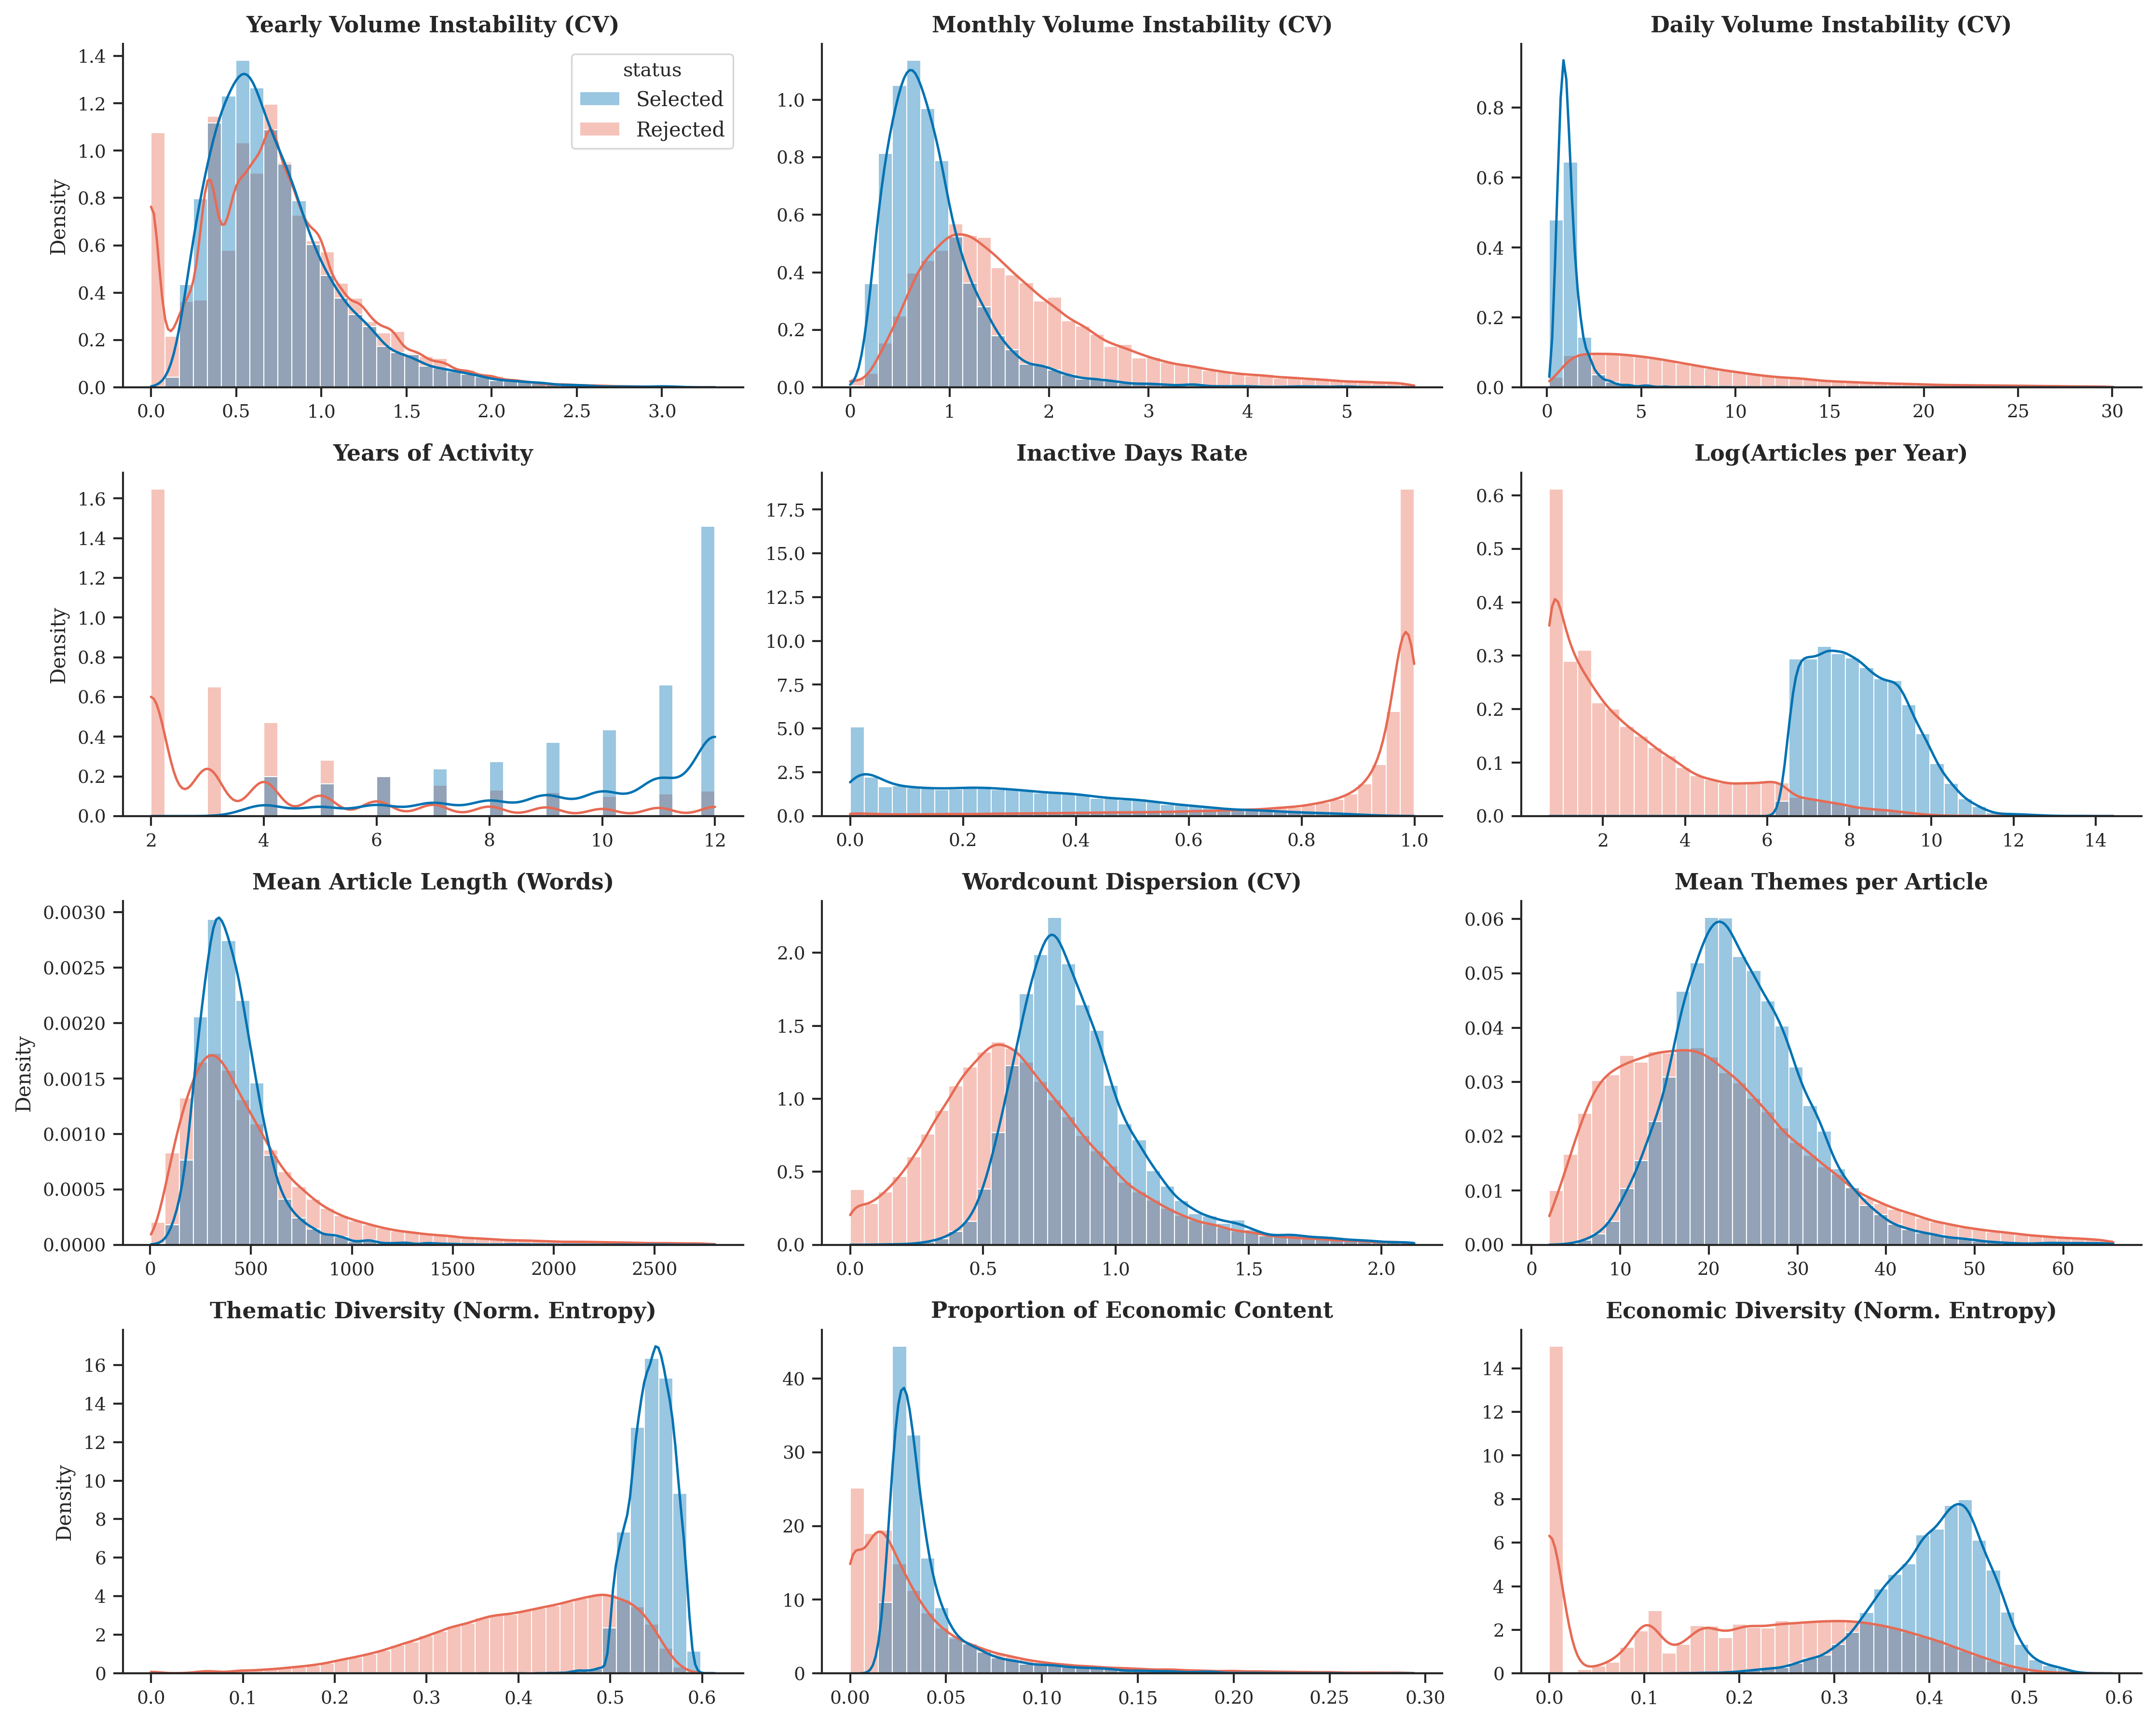

✔ Graphique sauvegardé sous : Fig_2_Boxplots_Selected_vs_Rejected.pdf


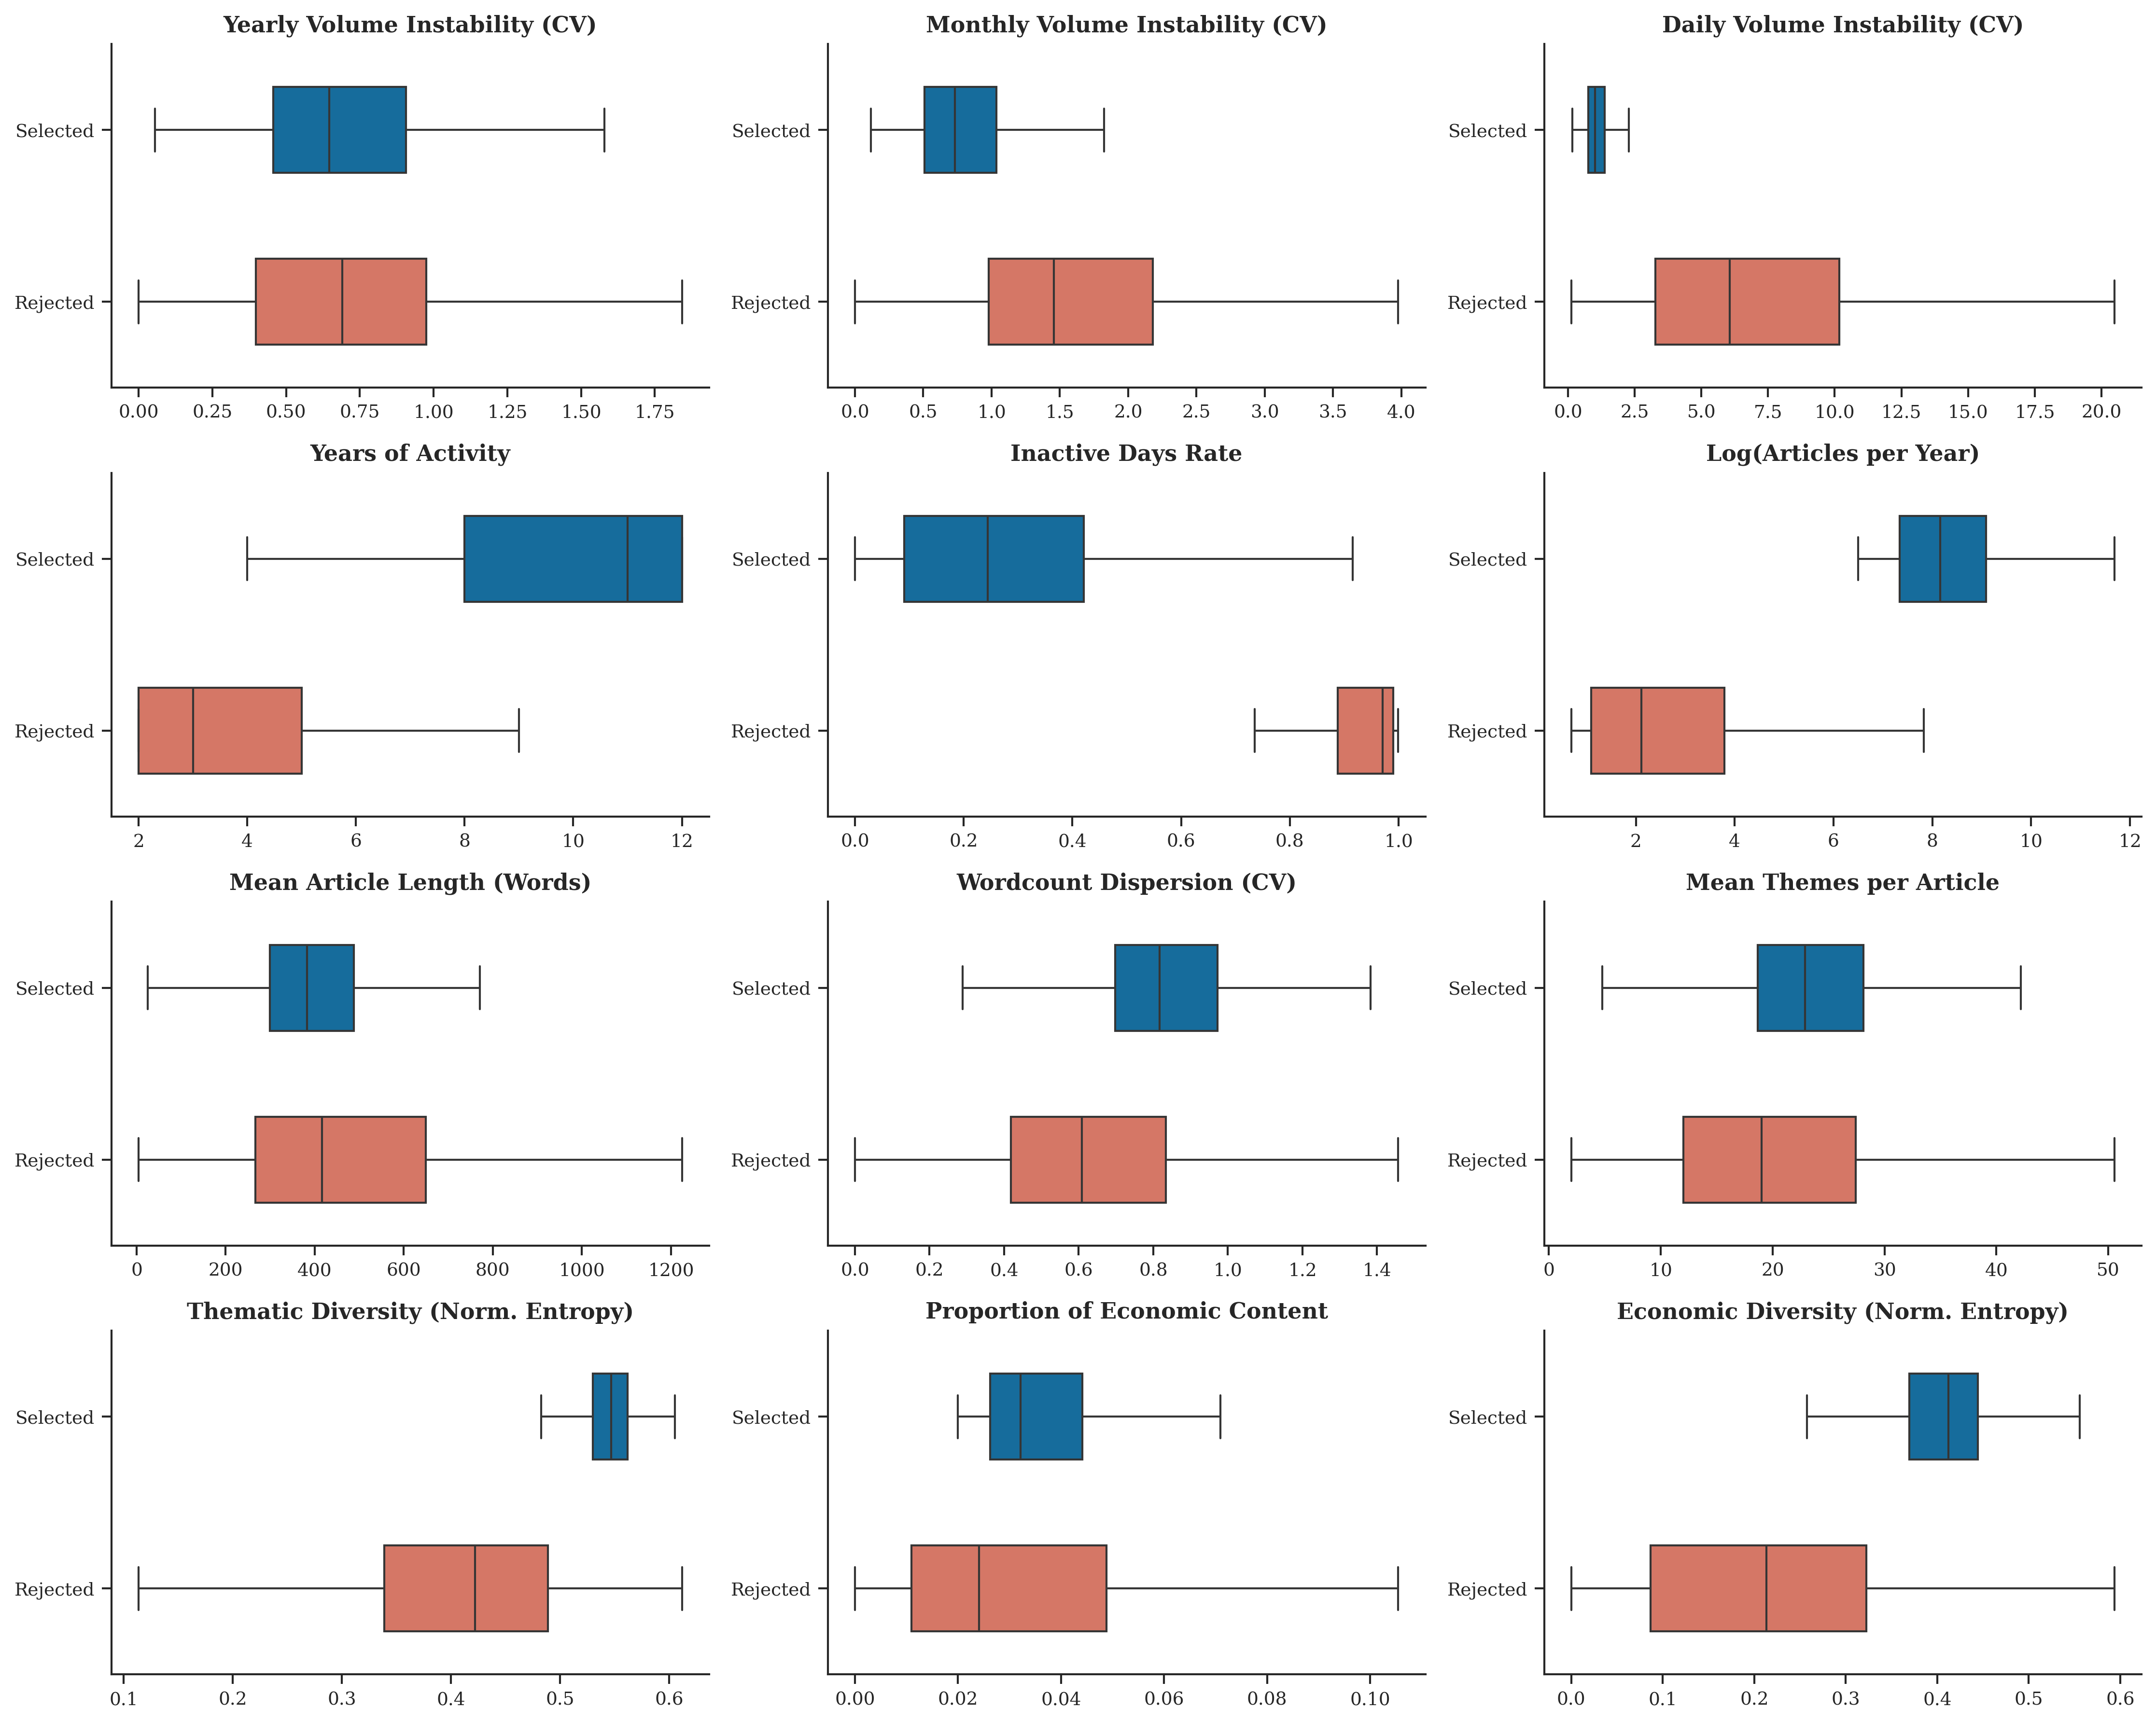

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ==============================================================================
# 1. CONFIGURATION "PUBLICATION-READY"
# ==============================================================================
sns.set_theme(style="ticks", context="paper")

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 10,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.spines.top": False,
    "axes.spines.right": False
})

ACADEMIC_PALETTE = {"Selected": "#0072B2", "Rejected": "#E76A54"}

# Dictionary for clean axis labels
FEATURE_LABELS = {
    "cv_yearly": "Yearly Volume Instability (CV)",
    "cv_monthly": "Monthly Volume Instability (CV)",
    "cv_daily": "Daily Volume Instability (CV)", 
    "years_active": "Years of Activity",
    "inactive_days_rate": "Inactive Days Rate",
    "log_total_articles_year": "Log(Articles per Year)",
    "mean_wordcount": "Mean Article Length (Words)",
    "cv_wordcount": "Wordcount Dispersion (CV)",
    "mean_themes_per_art": "Mean Themes per Article",
    "h_norm_themes": "Thematic Diversity (Norm. Entropy)",
    "ratio_eco": "Proportion of Economic Content",
    "h_norm_eco": "Economic Diversity (Norm. Entropy)",
}

# NEW ORDER: Forces the layout you requested (3 items per row)
features_to_plot = [
    "cv_yearly", "cv_monthly", "cv_daily",                     # Row 1: Instabilities
    "years_active", "inactive_days_rate", "log_total_articles_year", # Row 2: Volume & Time
    "mean_wordcount", "cv_wordcount", "mean_themes_per_art",   # Row 3: Article Profile
    "h_norm_themes", "ratio_eco", "h_norm_eco"                 # Row 4: Semantic Profile
]

# Features that need a 99th-percentile crop to avoid squashed charts
skewed_features = [
    "cv_daily", "cv_monthly", "mean_wordcount", 
    "cv_wordcount", "mean_themes_per_art", "ratio_eco"
]

# ==============================================================================
# 2. FONCTION DE TRACÉ ACADÉMIQUE
# ==============================================================================
def plot_academic_comparison(df_selected, df_rejected, kind="hist", filename="comparison_plot.pdf"):
    
    df_selected = df_selected.copy().assign(status="Selected")
    df_rejected = df_rejected.copy().assign(status="Rejected")
    df_plot = pd.concat([df_selected, df_rejected], ignore_index=True)

    fig, axes = plt.subplots(4, 3, figsize=(15, 12))
    axes = axes.flatten()

    for i, col in enumerate(features_to_plot):
        ax = axes[i]
        if col not in df_plot.columns:
            continue
            
        clean_label = FEATURE_LABELS.get(col, col)

        # ---------------------------------------------------------
        # FIX FOR BIN SIZES: Filter data BEFORE giving it to seaborn
        # ---------------------------------------------------------
        plot_data = df_plot.copy()
        if col in skewed_features:
            # Calculate global 99th percentile
            upper_limit = plot_data[col].quantile(0.99)
            # Slice the dataframe to drop extreme outliers
            plot_data = plot_data[plot_data[col] <= upper_limit]

        if kind == "hist":
            sns.histplot(
                data=plot_data,
                x=col,
                hue="status",
                stat="density",
                common_norm=False,
                kde=True,
                bins=40,       # Bins will now perfectly distribute across the cropped range!
                alpha=0.4,
                palette=ACADEMIC_PALETTE,
                ax=ax,
                legend=(i == 0),
                linewidth=0.5
            )
            ax.set_ylabel("Density" if i % 3 == 0 else "")
            
        else: # kind == "box"
            sns.boxplot(
                data=plot_data,
                x=col,
                y="status",
                hue="status",
                showfliers=False, 
                width=0.5,
                linewidth=1.0,
                palette=ACADEMIC_PALETTE,
                ax=ax,
                legend=False
            )
            ax.set_ylabel("")

        ax.set_title(clean_label, fontweight="bold")
        ax.set_xlabel("")
        sns.despine(ax=ax) 

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.savefig(filename)
    print(f"✔ Graphique sauvegardé sous : {filename}")
    plt.show()

# ==============================================================================
# 3. EXÉCUTION
# ==============================================================================
print("⏳ Génération des visualisations de sélection...")

# Trace et exporte la distribution (KDE/Histogram)
plot_academic_comparison(
    df_propre, 
    df_rejetes, 
    kind="hist", 
    filename="Fig_1_Distribution_Selected_vs_Rejected.pdf"
)

# Trace et exporte les Boxplots
plot_academic_comparison(
    df_propre, 
    df_rejetes, 
    kind="box", 
    filename="Fig_2_Boxplots_Selected_vs_Rejected.pdf"
)